<a href="https://colab.research.google.com/github/KevintheChris/Taxa-de-mortalidade-ao-longo-dos-anos-/blob/main/death_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Projeto: Análise Histórica da Carga Global de Doenças e Mortalidade (1970 - 2010)


Neste notebook, vamos explorar um conjunto de dados fascinante focado na Carga Global de Doenças, com estimativas fornecidas pelo Instituto de Métricas e Avaliação de Saúde (IHME). Nosso principal objetivo é investigar a evolução do número de mortes e das taxas de mortalidade ao longo de quatro décadas (avaliando os anos de 1970, 1980, 1990, 2000 e 2010).

Através de manipulação de dados e visualizações gráficas com Python, vamos responder a perguntas cruciais sobre a saúde pública global, como:
* Quais países lideram as taxas de mortalidade histórica?
* Como a América do Sul evoluiu ao longo do tempo em termos de mortes por 100 mil habitantes?
* Existem diferenças significativas de mortalidade entre gêneros e faixas etárias, especialmente com um olhar aprofundado para o Brasil?

---

### 📖 Dicionário de Variáveis

O nosso conjunto de dados é composto por 7 colunas fundamentais. Para facilitar a compreensão das análises seguintes, aqui está a definição de cada uma delas:

| Nome da Coluna | Tipo de Dado | Descrição |
| :--- | :--- | :--- |
| **Country Code** | Texto (String) | Código de três letras que representa o país (ex: AFG para Afeganistão). |
| **Country Name** | Texto (String) | Nome completo do país analisado. |
| **Year** | Número Inteiro (Int) | O ano exato em que os dados foram registrados. |
| **Age Group** | Texto (String) | A faixa etária dos indivíduos (ex: "0-6 days", "15-19 years", "All ages"). |
| **Sex** | Texto (String) | O gênero dos indivíduos categorizado como "Male" (Masculino), "Female" (Feminino) ou "Both" (Ambos). |
| **Number of Deaths** | Número Decimal (Float)* | O número absoluto total de mortes registradas para aquele grupo específico. |
| **Death Rate Per 100,000** | Número Decimal (Float)* | A proporção de mortes calculada a cada 100.000 habitantes, permitindo comparar populações de tamanhos diferentes. |

*(Nota: Algumas colunas numéricas podem precisar de tratamento prévio devido à formatação original do arquivo).*


In [ ]:
# Importando a biblioteca pandas, essencial para ler, manipular e analisar dados em formato de tabela (DataFrames)
import pandas as pd

# Importando a biblioteca matplotlib.pyplot, usada para criar gráficos e visualizações de dados básicas
import matplotlib.pyplot as plt

# Importando a biblioteca seaborn, usada para criar gráficos estatísticos mais atraentes e complexos (trabalha junto com o matplotlib)
import seaborn as sns

# Opcional, mas recomendado: configura o estilo visual padrão dos gráficos do seaborn para ficarem mais bonitos
sns.set_theme(style="whitegrid")

# Imprime uma mensagem na tela para confirmar que as bibliotecas foram carregadas com sucesso
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# A função pd.read_csv() lê o arquivo CSV e o transforma em uma tabela virtual chamada 'DataFrame' (df_mortalidade)
df_mortalidade = pd.read_csv('/arquivos_projeto/IHME_GBD_2010_MORTALITY_AGE_SPECIFIC_BY_COUNTRY_1970_2010.csv')

# A função .head() pega as 5 primeiras linhas do nosso conjunto de dados e as exibe na tela para visualizarmos a estrutura
display(df_mortalidade.head())

# A função .info() exibe um resumo do dataset, mostrando os nomes das colunas, quantos dados não-nulos existem e os tipos de dados (texto, número, etc.)
print("\n--- Informações Gerais do Dataset ---")
df_mortalidade.info()


,Country Code,Country Name,Year,Age Group,Sex,Number of Deaths,"Death Rate Per 100,000"
0,AFG,Afghanistan,1970,0-6 days,Male,"19,241","318,292.90"
1,AFG,Afghanistan,1970,0-6 days,Female,"12,600","219,544.20"
2,AFG,Afghanistan,1970,0-6 days,Both,"31,840","270,200.70"
3,AFG,Afghanistan,1970,7-27 days,Male,"15,939","92,701.00"
4,AFG,Afghanistan,1970,7-27 days,Female,"11,287","68,594.50"



--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58905 entries, 0 to 58904
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Country Code            58905 non-null  object
 1   Country Name            58905 non-null  object
 2   Year                    58905 non-null  int64 
 3   Age Group               58905 non-null  object
 4   Sex                     58905 non-null  object
 5   Number of Deaths        58905 non-null  object
 6   Death Rate Per 100,000  58905 non-null  object
dtypes: int64(1), object(6)
memory usage: 3.1+ MB


## Análise Estrutural do Dataset

Antes de começarmos a extrair estatísticas ou criar gráficos, precisamos entender as dimensões e a integridade da nossa tabela. Neste passo, vamos verificar a quantidade total de registros, identificar se existem dados ausentes (*missing values*) que precisem de tratamento, e descobrir a quantidade de países únicos e os anos exatos que cobrem a nossa base de dados.

In [ ]:
# 1. Verificando o número total de linhas
# A propriedade .shape retorna o formato da tabela como (linhas, colunas).
# Usamos [0] para selecionar apenas a quantidade de linhas.
numero_linhas = df_mortalidade.shape[0]
print(f"1. Número total de linhas no dataset: {numero_linhas}")
print("-" * 50) # Apenas imprimindo uma linha tracejada para organizar a visualização

# 2. Verificando a quantidade de dados faltantes (missings/nulos)
# A função .isnull() checa célula por célula e diz se ela está vazia.
# A função .sum() soma todos os vazios de cada coluna.
print("2. Quantidade de valores faltantes por coluna:")
missings = df_mortalidade.isnull().sum()
print(missings)
print("-" * 50)

# 3. Verificando a quantidade de países distintos
# A função .nunique() conta quantos valores ÚNICOS existem em uma coluna específica, ignorando as repetições.
qtd_paises = df_mortalidade['Country Name'].nunique()
print(f"3. Quantidade de países distintos disponíveis: {qtd_paises}")
print("-" * 50)

# 4. Verificando a quantidade e quais são os anos disponíveis
# Pegamos a quantidade de anos únicos
qtd_anos = df_mortalidade['Year'].nunique()

# A função .unique() nos mostra exatamente quais são esses valores (não apenas a quantidade)
anos_disponiveis = df_mortalidade['Year'].unique()

print(f"4. Quantidade de anos distintos no dataset: {qtd_anos}")
print(f"   Anos avaliados: {anos_disponiveis}")

1. Número total de linhas no dataset: 58905
--------------------------------------------------
2. Quantidade de valores faltantes por coluna:
Country Code              0
Country Name              0
Year                      0
Age Group                 0
Sex                       0
Number of Deaths          0
Death Rate Per 100,000    0
dtype: int64
--------------------------------------------------
3. Quantidade de países distintos disponíveis: 187
--------------------------------------------------
4. Quantidade de anos distintos no dataset: 5
   Anos avaliados: [1970 1980 1990 2000 2010]


## País com a Maior Média de Taxa de Mortalidade

Qual país tem a maior média de taxa de mortalidade por 100.000 indivíduos ao longo de todos os anos?

Nesta etapa, vamos descobrir qual país apresenta a maior média histórica de mortes por 100.000 habitantes, considerando todos os anos, idades e sexos disponíveis na base de dados. Para isso, utilizaremos a função de agrupamento de dados do Pandas.


In [ ]:
# 1. TRATAMENTO DOS DADOS (Data Cleaning)
# Pegamos a coluna alvo e fazemos uma cadeia de comandos:
# .astype(str) -> Garante que o Python está tratando tudo como texto inicialmente
# .str.replace(',', '') -> Procura as vírgulas e substitui por 'nada' (apagando-as)
# .astype(float) -> Converte o resultado final para número decimal (float)
df_mortalidade['Death Rate Per 100,000'] = df_mortalidade['Death Rate Per 100,000'].astype(str).str.replace(',', '').astype(float)

# Limpando a coluna 'Number of Deaths' da mesma forma que fizemos com as taxas
df_mortalidade['Number of Deaths'] = df_mortalidade['Number of Deaths'].astype(str).str.replace(',', '').astype(float)


# Imprimimos uma mensagem para confirmar a transformação
print("Tipo de dado da coluna após a limpeza:", df_mortalidade['Death Rate Per 100,000'].dtype)
print("-" * 50)

# 2. CÁLCULO DA MÉDIA POR PAÍS (Agrupamento)
# Agrupamos pelo nome do país e isolamos a coluna numérica que acabamos de limpar
dados_agrupados = df_mortalidade.groupby('Country Name')['Death Rate Per 100,000']

# Calculamos a média para cada país
media_por_pais = dados_agrupados.mean()

# Ordenamos do maior valor para o menor (descrescente)
media_ordenada = media_por_pais.sort_values(ascending=False)

# Isolamos apenas o 1º colocado
pais_maior_media = media_ordenada.head(1)

# 3. EXIBIÇÃO DO RESULTADO
print("--- País com a maior média de taxa de mortalidade (por 100.000 hab.) ---")
print(pais_maior_media)

Tipo de dado da coluna após a limpeza: float64
--------------------------------------------------
--- País com a maior média de taxa de mortalidade (por 100.000 hab.) ---
Country Name
Mali    16663.679683
Name: Death Rate Per 100,000, dtype: float64


## Tendência de Mortalidade na América do Sul ao Longo dos Anos
"Qual é a tendência na taxa de mortalidade por 100.000 indivíduos ao longo dos anos para os países da América do Sul? Trace um gráfico de linhas contendo todos os países e a evolução das mortes ao longo dos anos."

Para analisar uma região específica, precisamos primeiro filtrar o nosso conjunto de dados. Vamos criar uma lista com os nomes dos países da América do Sul (em inglês, como deve estar no dataset) e pedir para o Pandas manter apenas as linhas referentes a eles. Em seguida, vamos plotar um gráfico de linhas para observar a evolução temporal.

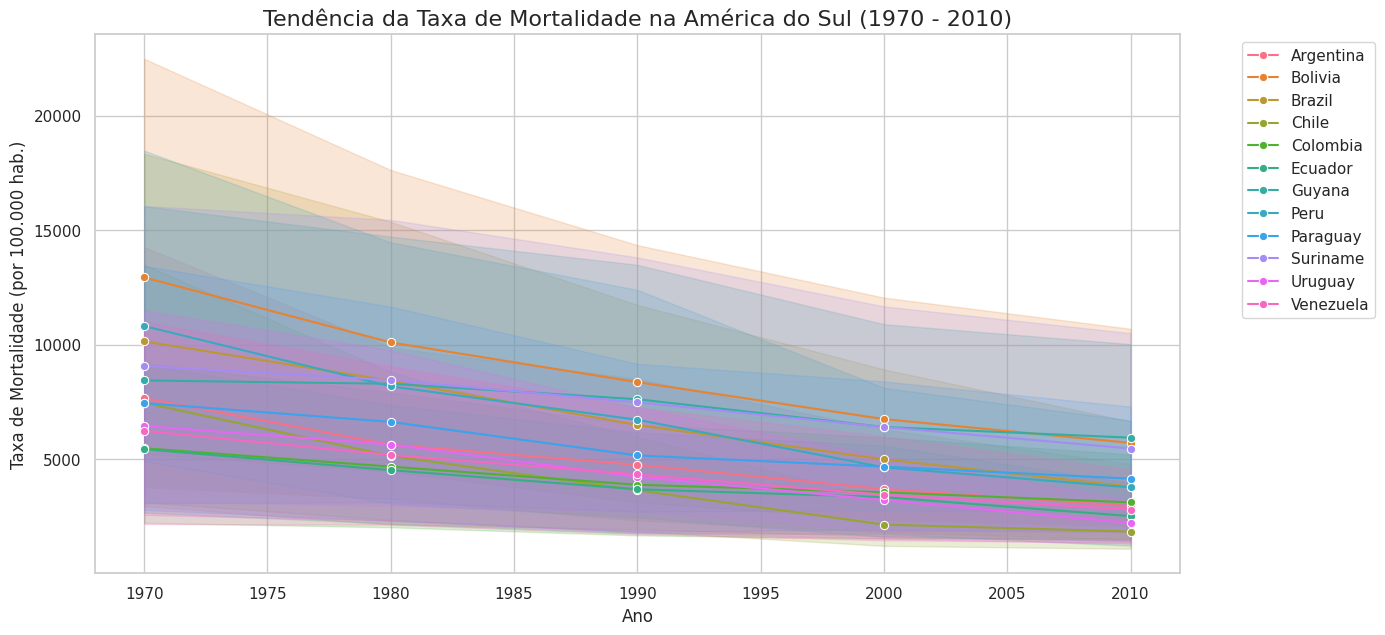

In [ ]:
# 1. CRIANDO O FILTRO DE PAÍSES
# Criamos uma lista com os nomes dos países da América do Sul
# Nota: Estou usando os nomes em inglês pois é o padrão da base do IHME.
paises_america_sul = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia',
    'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname',
    'Uruguay', 'Venezuela'
]

# A função .isin() verifica quais linhas da coluna 'Country Name' estão dentro da nossa lista.
# Salvamos esse recorte em uma nova variável chamada 'df_amsul' (Dataframe da América do Sul)
df_amsul = df_mortalidade[df_mortalidade['Country Name'].isin(paises_america_sul)]

# 2. CRIANDO O GRÁFICO DE LINHAS
# plt.figure(figsize=(largura, altura)) define o tamanho do "quadro" do nosso gráfico
plt.figure(figsize=(14, 7))

# O seaborn (sns) cria o gráfico de linhas (lineplot)
# data: nossa tabela filtrada
# x e y: as colunas que vão nos eixos
# hue: a coluna que vai colorir as linhas (uma cor para cada país)
# marker='o': coloca uma bolinha marcando exatamente onde estão os dados de cada ano
sns.lineplot(data=df_amsul, x='Year', y='Death Rate Per 100,000', hue='Country Name', marker='o')

# 3. EMBELEZANDO O GRÁFICO
# Adicionando título e rótulos aos eixos para facilitar a leitura
plt.title('Tendência da Taxa de Mortalidade na América do Sul (1970 - 2010)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Taxa de Mortalidade (por 100.000 hab.)', fontsize=12)

# Ajustando a legenda para ficar fora do gráfico e não cobrir as linhas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# O comando plt.show() exibe o gráfico finalizado na tela
plt.show()

## Diferenças de Mortalidade entre Sexos por Grupo Etário na América do Sul

Existem diferenças significativas nas taxas de mortalidade entre homens e mulheres em diferentes grupos etários para os países da América do Sul?

Nesta etapa, focaremos na comparação entre homens e mulheres de acordo com a idade, dentro da América do Sul. Vamos filtrar nossa base para remover a categoria que engloba "Ambos" os sexos e construiremos um gráfico de barras.

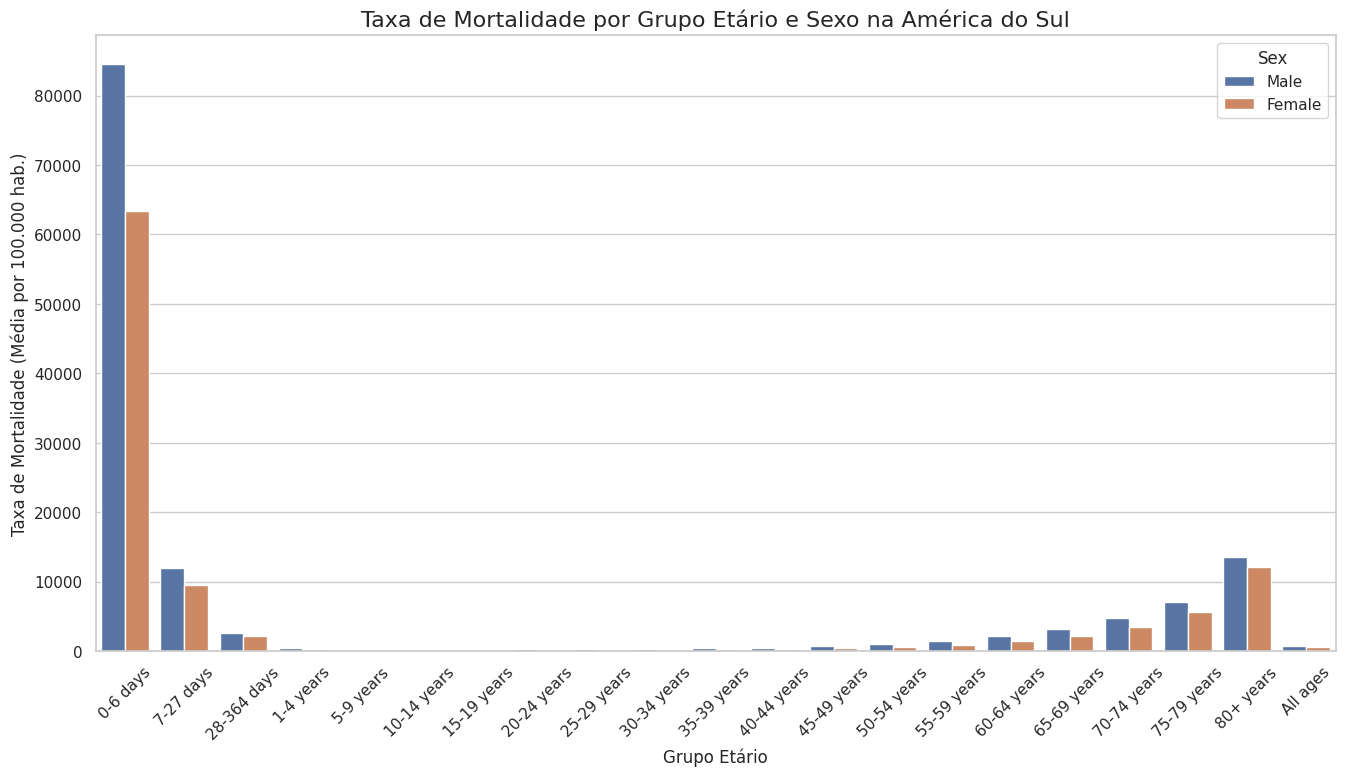

In [ ]:
# 1. FILTRANDO OS SEXOS
# Vamos manter apenas as linhas onde a coluna 'Sex' seja 'Male' (Masculino) ou 'Female' (Feminino)
# Isso remove a categoria 'Both' (Ambos) para não distorcer o gráfico.
df_amsul_sexo = df_amsul[df_amsul['Sex'].isin(['Male', 'Female'])]

# 2. CRIANDO O GRÁFICO DE BARRAS
# Definimos o tamanho da figura
plt.figure(figsize=(16, 8))

# O seaborn cria o gráfico de barras (barplot)
# Ele automaticamente calcula a média da taxa de mortalidade para cada grupo etário e divide por sexo (hue)
# errorbar=None retira uma linha de "margem de erro" visual que o seaborn coloca por padrão, deixando mais limpo
sns.barplot(data=df_amsul_sexo, x='Age Group', y='Death Rate Per 100,000', hue='Sex', errorbar=None)

# 3. EMBELEZANDO O GRÁFICO
plt.title('Taxa de Mortalidade por Grupo Etário e Sexo na América do Sul', fontsize=16)
plt.xlabel('Grupo Etário', fontsize=12)
plt.ylabel('Taxa de Mortalidade (Média por 100.000 hab.)', fontsize=12)

# plt.xticks() nos permite girar o texto do eixo X.
# Como temos muitas idades, girar em 45 ou 90 graus evita que os textos fiquem sobrepostos.
plt.xticks(rotation=45)

# Exibe o gráfico
plt.show()

## Distribuição da Mortalidade por Faixa Etária no Brasil
Como a taxa de mortalidade por 100.000 indivíduos varia entre diferentes grupos etários dentro do Brasil? Utilize um histograma contendo a distribuição das mortes por ano para cada uma das faixas etárias.

Nesta etapa, filtramos o dataset original para isolar apenas as informações do Brasil. Em seguida, utilizamos um gráfico de barras agrupadas para visualizar como a taxa de mortalidade se distribui entre os diferentes grupos etários em cada um dos anos registrados na base de dados.

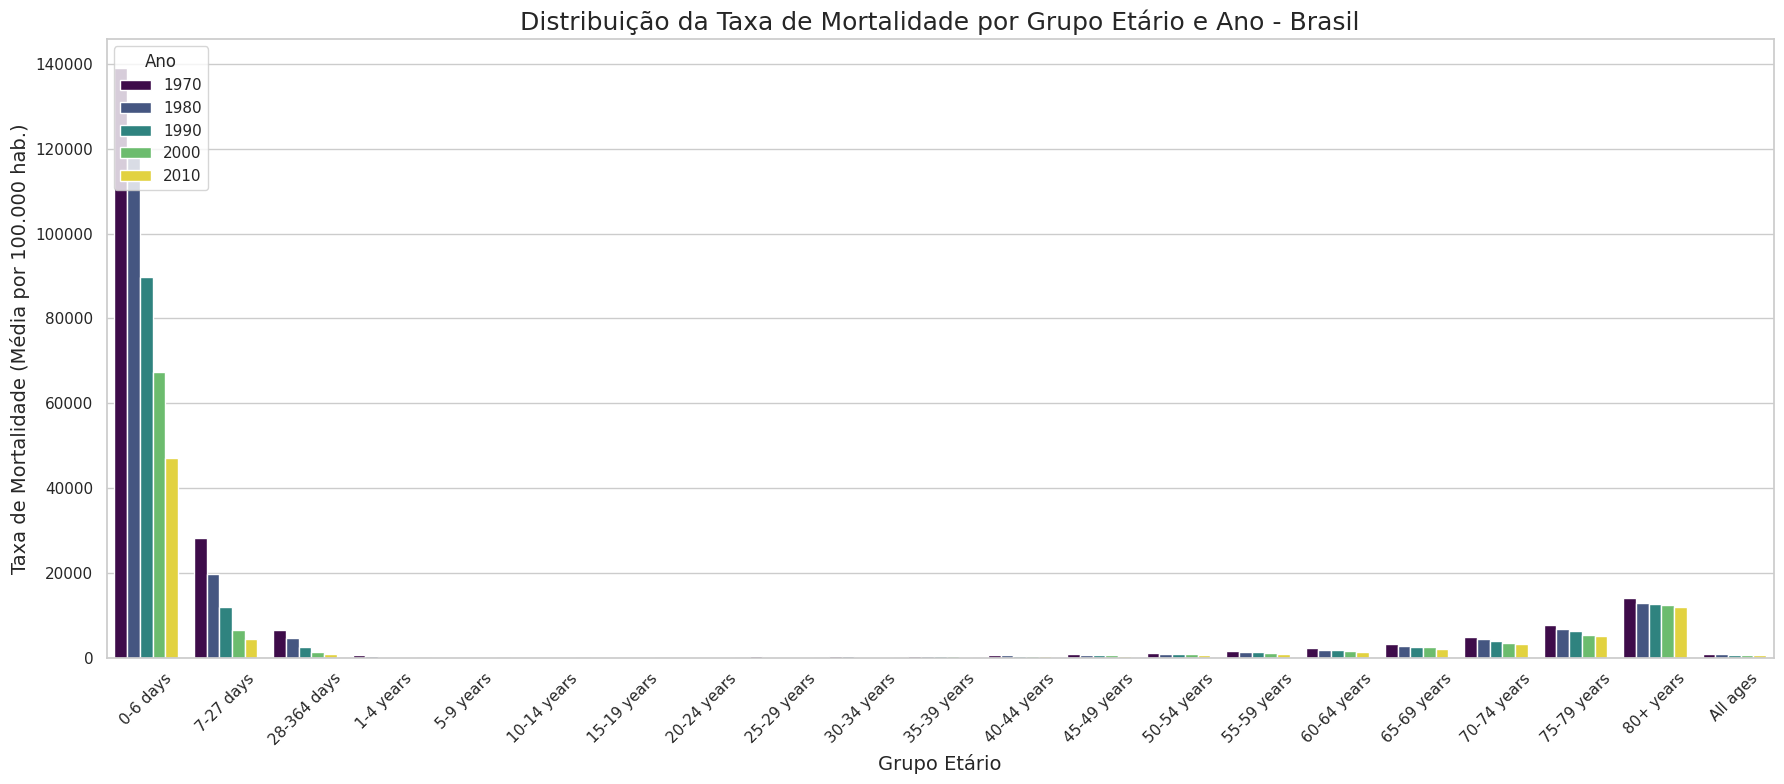

In [ ]:
# 1. FILTRANDO OS DADOS PARA O BRASIL
# O .copy() no final garante que estamos criando uma tabela nova e independente na memória, evitando avisos do Pandas
df_brasil = df_mortalidade[df_mortalidade['Country Name'] == 'Brazil'].copy()

# 2. CONFIGURANDO E CRIANDO O GRÁFICO
plt.figure(figsize=(18, 8))

# Agora com os dados 100% numéricos, o barplot vai desenhar as barras para cima e com uma escala limpa
sns.barplot(
    data=df_brasil,
    x='Age Group',
    y='Death Rate Per 100,000',
    hue='Year',
    errorbar=None,
    palette='viridis'
)

# 3. EMBELEZANDO O GRÁFICO
plt.title('Distribuição da Taxa de Mortalidade por Grupo Etário e Ano - Brasil', fontsize=18)
plt.xlabel('Grupo Etário', fontsize=14)
plt.ylabel('Taxa de Mortalidade (Média por 100.000 hab.)', fontsize=14)

# Rotacionando os rótulos do eixo X em 45 graus
plt.xticks(rotation=45)

# Ajustando a legenda
plt.legend(title='Ano', loc='upper left')

# O tight_layout ajusta as margens para o gráfico ficar bem enquadrado
plt.tight_layout()

# Exibimos o gráfico corrigido
plt.show()

##  Evolução do Número de Mortes por Gênero no Brasil

Qual a evolução das mortes por gênero pra o Brasil? Trace um gráfico de linhas com cada uma delas representando um dos gêneros ao longo dos anos.

Para entender o volume absoluto de óbitos entre homens e mulheres no Brasil ao longo das décadas, primeiro faremos a limpeza da coluna `Number of Deaths` (removendo possíveis vírgulas). Em seguida, agruparemos esses dados para traçar um gráfico de linhas mostrando a evolução temporal de cada gênero.

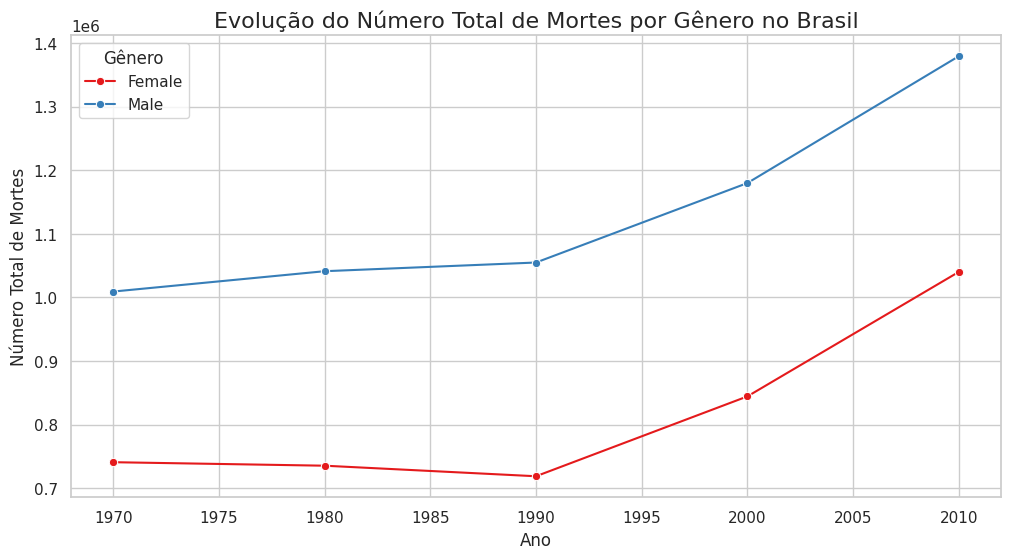

In [ ]:
# 1. FILTRANDO BRASIL E GÊNEROS
# Queremos apenas Brasil e queremos excluir a categoria 'Both' (Ambos) para não haver contagem duplicada
df_br_genero = df_mortalidade[(df_mortalidade['Country Name'] == 'Brazil') & (df_mortalidade['Sex'].isin(['Male', 'Female']))]

# Como a base tem várias idades, precisamos SOMAR o número de mortes por Ano e por Sexo
# O .reset_index() transforma o resultado de volta em uma tabela normal
df_br_genero_agrupado = df_br_genero.groupby(['Year', 'Sex'])['Number of Deaths'].sum().reset_index()

# 2. CRIANDO O GRÁFICO DE LINHAS
plt.figure(figsize=(12, 6))

# data: nossa tabela recém agrupada
# x = Ano, y = Soma das Mortes, hue = Separação por linha e cor baseada no Sexo
sns.lineplot(data=df_br_genero_agrupado, x='Year', y='Number of Deaths', hue='Sex', marker='o', palette='Set1')

# 3. EMBELEZANDO O GRÁFICO
plt.title('Evolução do Número Total de Mortes por Gênero no Brasil', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número Total de Mortes', fontsize=12)
plt.legend(title='Gênero')
plt.show()

## Grupo Etário com Maior Número de Mortes no Brasil
Qual grupo etário tem o maior número de mortes no Brasil? Este número é o mesmo quando olhamos para todos os anos em comparação com quando consideramos apenas os últimos 10 anos?

Nesta análise, identificaremos qual faixa etária concentra o maior número absoluto de mortes. Faremos uma comparação em dois cenários: o período histórico completo (1970 - 2010) e o cenário mais recente do dataset (últimos 10 anos, de 2000 a 2010).

In [ ]:
# 1. PREPARANDO OS DADOS DO BRASIL COM FILTROS AVANÇADOS
# Adicionamos uma terceira regra: (df_mortalidade['Age Group'] != 'All ages')
# Os parênteses isolam cada regra, e os '&' exigem que todas sejam verdadeiras ao mesmo tempo.
df_br_idades = df_mortalidade[
    (df_mortalidade['Country Name'] == 'Brazil') &
    (df_mortalidade['Sex'] != 'Both') &
    (df_mortalidade['Age Group'] != 'All ages')
]

# 2. CENÁRIO 1: TODOS OS ANOS
# Agrupamos pelas faixas etárias reais, somamos e ordenamos do maior para o menor
mortes_por_idade_todos_anos = df_br_idades.groupby('Age Group')['Number of Deaths'].sum().sort_values(ascending=False)

maior_grupo_todos = mortes_por_idade_todos_anos.index[0] # Nome da faixa etária no topo
valor_maior_todos = mortes_por_idade_todos_anos.iloc[0]  # Número de mortes

# 3. CENÁRIO 2: ÚLTIMOS 10 ANOS (2000 a 2010)
# Filtramos a base já corrigida (df_br_idades) para pegar apenas os anos >= 2000
df_br_ultimos_10 = df_br_idades[df_br_idades['Year'] >= 2000]

mortes_por_idade_10_anos = df_br_ultimos_10.groupby('Age Group')['Number of Deaths'].sum().sort_values(ascending=False)

maior_grupo_10 = mortes_por_idade_10_anos.index[0]
valor_maior_10 = mortes_por_idade_10_anos.iloc[0]

# 4. EXIBINDO OS RESULTADOS CORRIGIDOS
print("--- Análise de Mortes por Grupo Etário Específico no Brasil ---")
print(f"Considerando TODOS os anos (1970-2010):")
print(f"O grupo com mais mortes é '{maior_grupo_todos}' com {valor_maior_todos:,.0f} mortes.")
print("-" * 50)
print(f"Considerando apenas os ÚLTIMOS 10 ANOS (2000-2010):")
print(f"O grupo com mais mortes é '{maior_grupo_10}' com {valor_maior_10:,.0f} mortes.")

--- Análise de Mortes por Grupo Etário Específico no Brasil ---
Considerando TODOS os anos (1970-2010):
O grupo com mais mortes é '80+ years' com 793,258 mortes.
--------------------------------------------------
Considerando apenas os ÚLTIMOS 10 ANOS (2000-2010):
O grupo com mais mortes é '80+ years' com 548,774 mortes.


## País com a Melhoria Mais Significativa (1970 vs 2010)


7. Qual país apresentou a melhoria mais significativa nas taxas de mortalidade por 100.000 indivíduos ao longo do período analisado?


Para encontrar qual país mais reduziu sua taxa de mortalidade ao longo do período analisado, calcularemos a diferença entre a taxa média de mortalidade do ano de 1970 e a do ano de 2010. O país com a maior diferença positiva será o que apresentou a melhoria mais significativa.

In [ ]:
# 1. CRIANDO A TABELA CRUZADA (PIVOT TABLE)
# A tabela dinâmica organiza os países nas linhas e os anos nas colunas, preenchendo o meio com a média da taxa de mortalidade
tabela_evolucao = pd.pivot_table(
    df_mortalidade,
    values='Death Rate Per 100,000',
    index='Country Name',
    columns='Year',
    aggfunc='mean'
)

# 2. CALCULANDO A MELHORIA
# Subtraímos a taxa de 2010 (mais recente) da taxa de 1970 (mais antiga).
# Se o número cair (ex: era 1000 e virou 200), o resultado será positivo (800 de melhoria).
tabela_evolucao['Melhoria (1970-2010)'] = tabela_evolucao[1970] - tabela_evolucao[2010]

# 3. IDENTIFICANDO O PAÍS VENCEDOR
# Ordenamos pela nova coluna 'Melhoria' do maior para o menor
paises_melhoria_ordenados = tabela_evolucao.sort_values(by='Melhoria (1970-2010)', ascending=False)

# Pegamos apenas a primeira linha (país com a maior diferença)
top_pais_melhoria = paises_melhoria_ordenados.head(1)[['Melhoria (1970-2010)']]

# 4. EXIBINDO O RESULTADO
print("--- País com a melhoria mais significativa nas taxas de mortalidade ---")
print("Queda absoluta na taxa média por 100.000 hab. entre 1970 e 2010:")
print(top_pais_melhoria)

--- País com a melhoria mais significativa nas taxas de mortalidade ---
Queda absoluta na taxa média por 100.000 hab. entre 1970 e 2010:
Year          Melhoria (1970-2010)
Country Name                      
Maldives              15301.042857


## Criação do Dashboard Interativo com Streamlit

Nesta etapa final, vamos consolidar nossas análises em um Dashboard Web interativo utilizando a biblioteca `streamlit`. Como estamos no ambiente do Google Colab, primeiro instalaremos a biblioteca e, em seguida, escreveremos todo o código do nosso aplicativo em um arquivo separado chamado `app.py`. Por fim, usaremos um túnel local para acessar a página web gerada.

### Escrevendo o Código do Dashboard (`app.py`)
O comando `%%writefile app.py` na primeira linha da célula abaixo diz ao Colab para não executar o código imediatamente, mas sim salvá-lo em um arquivo de texto no menu lateral. Este arquivo conterá toda a nossa lógica de importação, limpeza e criação dos gráficos adaptada para a tela do Streamlit.

In [ ]:
# 1. INSTALANDO O STREAMLIT
# O ponto de exclamação (!) diz ao Colab para rodar isso no terminal da máquina virtual, não no Python
!pip install -q streamlit
print("Streamlit instalado com sucesso!")

Streamlit instalado com sucesso!


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÃO DA PÁGINA
st.set_page_config(page_title="Dashboard de Mortalidade", layout="wide")
sns.set_theme(style="whitegrid")

st.title("🌍 Dashboard: Análise Histórica de Mortalidade (1970 - 2010)")
st.markdown("Este dashboard interativo apresenta os dados da Carga Global de Doenças estimados pelo IHME.")

# 2. CARREGAMENTO E LIMPEZA DOS DADOS
@st.cache_data
def carregar_dados():
    # OBSERVAÇÃO: Coloque o nome correto do seu arquivo CSV aqui!
    df = pd.read_csv('/arquivos_projeto/IHME_GBD_2010_MORTALITY_AGE_SPECIFIC_BY_COUNTRY_1970_2010.csv')

    df['Death Rate Per 100,000'] = df['Death Rate Per 100,000'].astype(str).str.replace(',', '').astype(float)
    df['Number of Deaths'] = df['Number of Deaths'].astype(str).str.replace(',', '').astype(float)
    return df

df_mortalidade = carregar_dados()

# 3. CRIANDO 4 ABAS PARA ORGANIZAR O DASHBOARD
aba1, aba2, aba3, aba4 = st.tabs(["📊 Visão Geral", "🌎 América do Sul", "🇧🇷 Mortalidade no Brasil", "🚻 Evolução por Gênero (BR)"])

# --- CONTEÚDO DA ABA 1: VISÃO GERAL (OS NOVOS DADOS!) ---
with aba1:
    st.header("Resumo do Conjunto de Dados")

    # Criando 4 colunas para colocar os números lado a lado
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total de Registros", "58.905")
    col2.metric("Países Analisados", "187")
    col3.metric("Período (Anos)", "1970 a 2010")
    col4.metric("Dados Faltantes", "0 (Base Limpa)")

    st.markdown("---") # Linha divisória
    st.subheader("🏆 Recordes Globais")

    # Criando cartões coloridos para os insights mundiais
    st.error("**Pior Média Histórica:** O país **Mali** lidera com a maior média de taxa de mortalidade ao longo dos anos (16.663 mortes por 100.000 hab.)")
    st.success("**Maior Melhoria:** As **Maldivas** apresentaram a evolução mais significativa, com uma queda absoluta de 15.301 mortes por 100.000 hab. entre 1970 e 2010.")

# --- CONTEÚDO DA ABA 2: AMÉRICA DO SUL ---
with aba2:
    st.header("Tendência de Mortalidade na América do Sul")
    paises_america_sul = ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
    df_amsul = df_mortalidade[df_mortalidade['Country Name'].isin(paises_america_sul)]

    fig1, ax1 = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=df_amsul, x='Year', y='Death Rate Per 100,000', hue='Country Name', marker='o', ax=ax1)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    st.pyplot(fig1)

# --- CONTEÚDO DA ABA 3: BRASIL (IDADE X ANO) ---
with aba3:
    st.header("Distribuição por Grupo Etário no Brasil")

    # Adicionando o insight sobre os 80+ anos em um cartão de aviso!
    st.warning("⚠️ **Insight Etário:** O grupo **'80+ years'** concentra o maior número absoluto de mortes. Foram **793.258 mortes** considerando todo o período histórico (1970-2010), sendo que a maior parte (**548.774 mortes**) ocorreu apenas na última década analisada (2000-2010).")

    df_brasil = df_mortalidade[df_mortalidade['Country Name'] == 'Brazil'].copy()

    fig2, ax2 = plt.subplots(figsize=(14, 6))
    sns.barplot(data=df_brasil, x='Age Group', y='Death Rate Per 100,000', hue='Year', errorbar=None, palette='viridis', ax=ax2)
    plt.xticks(rotation=45)
    st.pyplot(fig2)

# --- CONTEÚDO DA ABA 4: BRASIL (GÊNERO) ---
with aba4:
    st.header("Evolução de Mortes por Gênero no Brasil")
    df_br_genero = df_mortalidade[(df_mortalidade['Country Name'] == 'Brazil') & (df_mortalidade['Sex'].isin(['Male', 'Female']))]
    df_br_genero_agrupado = df_br_genero.groupby(['Year', 'Sex'])['Number of Deaths'].sum().reset_index()

    fig3, ax3 = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=df_br_genero_agrupado, x='Year', y='Number of Deaths', hue='Sex', marker='o', palette='Set1', ax=ax3)
    st.pyplot(fig3)

Overwriting app.py


### Executando o Servidor e Acessando o Dashboard
Agora vamos rodar o Streamlit em segundo plano e usar o `localtunnel` para gerar um link de acesso. O código abaixo também vai imprimir um "IP (Senha)". Quando você clicar no link gerado pelo túnel, uma página de segurança pedirá uma senha (*Endpoint IP*), basta colar o número gerado aqui.

In [ ]:
# 1. Pegando o IP da máquina virtual do Colab (Esta será a sua "Senha" de acesso no site do túnel)
import urllib
senha_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print(f"🔑 SUA SENHA DE ACESSO É: {senha_ip}")
print("-" * 50)

# 2. Rodando o Streamlit em segundo plano
!streamlit run app.py &>/content/logs.txt &

# 3. Criando o link público com o localtunnel (Agora com o '-y' para aceitar a instalação automaticamente)
!npx -y localtunnel --port 8501

🔑 SUA SENHA DE ACESSO É: 34.9.63.167
--------------------------------------------------
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼your url is: https://poor-sides-think.loca.lt
^C


---
## Conclusão do Projeto

Chegamos ao fim desta jornada de análise exploratória de dados! O que começou como um arquivo bruto com mais de 58 mil registros se transformou em um painel interativo repleto de *insights* sobre a saúde pública global.

**Principais Descobertas:**
1. **O Peso da História:** Descobrimos que o Mali carrega a taxa de mortalidade média mais alta do período, enquanto as Maldivas mostraram ao mundo que é possível ter uma recuperação extraordinária, apresentando a maior queda nas taxas de mortalidade em quatro décadas.
2. **América do Sul e Brasil:** Observamos uma tendência geral de queda nas taxas de mortalidade na América do Sul. No entanto, ao focar no Brasil, notamos que o número absoluto de mortes aumentou com o passar dos anos, impulsionado pelo envelhecimento populacional (com o grupo de 80+ anos liderando as estatísticas na última década analisada).
3. **Diferenças de Gênero:** Os dados confirmaram de forma visual que, historicamente, o número de mortes masculinas no Brasil é superior ao de mortes femininas.

**Habilidades Aplicadas:**
Durante este projeto, aplicamos limpeza e tratamento de dados, agrupamentos complexos, criação de gráficos de linhas e barras com `Seaborn` e `Matplotlib`, e encerramos com a construção de um dashboard interativo utilizando `Streamlit`.

Obrigado por acompanhar esta análise!